# Expoloratory Data Analysis (EDA)

Разведочный анализ данных. Нахождение закономерностей и проблем в исходном датасете.


## Загрузка данных

Загрузим исходные данные.

In [144]:
import pandas as pd

path = "../data/raw/android_games_eda_ready.csv"
df = pd.read_csv(path)
df.head()

,game_id,game_name,developer_name,package_name,genre,sub_genre,monetization_model,contains_ads,has_in_app_purchases,multiplayer_support,...,has_seasonal_event,cross_platform_available,cloud_save_support,is_hit_game,post_30d_revenue_usd,post_30d_rating_count,featured_duration_days,store_platform,country_code_primary,row_checksum_id
0,622,Game_622_Arena,Studio_205,com.studio1664.game622,Casual,Party Game,Freemium,Yes,Yes,NaN,...,False,True,True,0,9963.75,6328,NaN,Android,IN,CHK_100621
1,4386,Game_4386_Rush,Studio_923,com.studio1615.game4386,RPG,Idle RPG,Free,Yes,No,Online,...,False,True,False,0,17880.43,9346,NaN,Android,IN,CHK_104385
2,6795,Game_6795_Tycoon,Studio_921,com.studio44.game6795,RPG,Idle RPG,Free,Yes,No,NaN,...,True,False,False,0,6060.03,4096,7.0,Android,BR,CHK_106794
3,4563,Game_4563_Quest,Studio_1873,com.studio1353.game4563,Casual,Idle Clicker,Paid,No,Yes,NaN,...,False,False,False,0,816621.72,12402,NaN,Android,US,CHK_104562
4,9265,Game_9265_Legends,Studio_1608,com.studio1308.game9265,RPG,MMORPG,Free,Yes,No,NaN,...,True,False,True,0,159839.20,7517,NaN,Android,IN,CHK_109264


## Первичный анализ данных

Проанализируем данные и выявим:
* общую информацию о размере
* типы данных и количество уникальных
* основные статистики числовых признаков
* пропуски и дубликаты

In [145]:
import numpy as np

### Размер датасета

In [146]:
print(f"Строк: {df.shape[0]}, столбцов: {df.shape[1]}")

Строк: 10150, столбцов: 57


### Типы данных

In [147]:
print(df.dtypes.value_counts())

str        23
float64    21
int64       8
bool        5
Name: count, dtype: int64


### Количество уникальных значений для каждого столбца

In [148]:
for col in df.columns:
    uniq = df[col].nunique()
    print(f"{col}: {uniq} уникальных")

game_id: 10000 уникальных
game_name: 10000 уникальных
developer_name: 2222 уникальных
package_name: 10000 уникальных
genre: 8 уникальных
sub_genre: 31 уникальных
monetization_model: 4 уникальных
contains_ads: 2 уникальных
has_in_app_purchases: 2 уникальных
multiplayer_support: 3 уникальных
age_rating: 3 уникальных
art_style: 5 уникальных
engine_used: 4 уникальных
region_focus: 6 уникальных
publisher_tier: 4 уникальных
event_theme: 5 уникальных
release_date: 2819 уникальных
soft_launch_date: 2872 уникальных
last_update_date: 3140 уникальных
was_featured_on_store: 2 уникальных
featured_start_date: 2029 уникальных
featured_end_date: 1988 уникальных
price_usd: 688 уникальных
downloads: 9855 уникальных
retention_day1_pct: 3463 уникальных
retention_day7_pct: 2581 уникальных
retention_day30_pct: 1673 уникальных
active_users_30d: 8250 уникальных
avg_session_minutes: 2972 уникальных
avg_daily_sessions: 575 уникальных
crash_rate_pct: 661 уникальных
apk_size_mb: 8310 уникальных
update_frequency_d

### Числовые признаки

In [149]:
display(df.describe(include=[np.number]).T)

,count,mean,std,min,25%,50%,75%,max
game_id,10150.0,4999.301970,2.886833e+03,1.00,2502.2500,4997.500,7501.7500,10000.00
price_usd,10150.0,0.699186,1.805539e+00,-4.94,0.0000,0.000,0.0000,24.70
downloads,10150.0,319704.915862,1.265406e+06,1061.00,46301.0000,110428.500,267512.2500,53450424.00
retention_day1_pct,10150.0,30.215609,9.157124e+00,5.00,23.7000,29.550,36.1700,68.74
retention_day7_pct,10150.0,16.693777,6.229105e+00,2.00,12.1200,15.900,20.5200,47.48
retention_day30_pct,10150.0,7.945300,3.761827e+00,1.00,5.1700,7.280,10.0000,25.00
active_users_30d,10150.0,20166.194778,4.418765e+04,62.00,2894.5000,7482.500,19502.7500,1020550.00
avg_session_minutes,10150.0,19.627916,7.686156e+00,3.00,14.2800,19.570,24.8900,47.48
avg_daily_sessions,10150.0,3.342308,1.021145e+00,0.50,2.6600,3.350,4.0200,7.17
crash_rate_pct,10150.0,2.525782,1.430158e+00,-2.78,1.4900,2.495,3.5000,8.83


### Пропуски

In [150]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Пропусков': missing, '%': missing_pct})
missing_df = missing_df[missing_df['Пропусков'] > 0].sort_values('Пропусков', ascending=False)
display(missing_df)

,Пропусков,%
event_theme,7682,75.684729
featured_duration_days,6984,68.807882
featured_end_date,6808,67.073892
featured_start_date,6805,67.044335
multiplayer_support,4066,40.059113
soft_launch_date,1012,9.970443
marketing_spend_usd,807,7.950739
arppu_usd,708,6.975369
cpi_usd,509,5.014778


### Дубликаты

In [151]:
full_dups = df.duplicated().sum()

print(f"Полных дубликатов строк: {full_dups}")

Полных дубликатов строк: 150


### Выводы
- **Размер**: 10150 строк, 57 столбцов.
- **Типы данных**:
  * 6 булевых (bool)
  * 8 целочисленных (int64)
  * 11 вещественных (float64)
  * 32 — строковые (object)
    - Многие строковые колонки по сути категориальные
- **Пропуски**: 9 столбцов имеют пропуски. Наибольшая доля у `event_theme` (75.7%) и `featured_duration_days` (68.8%).
- **Дубликаты**: 150 полных дубликатов строк - их необходимо удалить.
- **Константные / бесполезные колонки**: `store_platform` (только "Android"), `game_id` и `row_checksum_id` (идентификаторы), `package_name` (10 000 уникальных). Их удаление сократит размерность без потери информации.

---

## Первичная обработка данных

Теперь обработаем данные.

### Удаление дубликатов

In [152]:
df = df.drop_duplicates()
print("Размер после удаления полных дубликатов:", df.shape)

Размер после удаления полных дубликатов: (10000, 57)


### Удаление заведомо неинформативных столбцов

In [153]:
cols_to_drop = ['store_platform', 'row_checksum_id', 'game_id', 'game_name', 'package_name']
df = df.drop(columns=cols_to_drop)
print("Размер после удаления неинформативных столбцов:", df.shape)

Размер после удаления неинформативных столбцов: (10000, 52)


### Исправление типов

#### Bool

Удостоверимся, что колонки имеют тип bool.

In [154]:
bool_cols = ['contains_ads', 'has_in_app_purchases', 'was_featured_on_store',
             'is_weekend_release', 'has_seasonal_event', 'cross_platform_available', 'cloud_save_support']
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].astype(bool)

#### Category

Категориальные колонки преобразуем в category.

In [155]:
cat_cols = ['genre', 'sub_genre', 'monetization_model', 'multiplayer_support',
            'age_rating', 'art_style', 'engine_used', 'region_focus', 'publisher_tier',
            'event_theme', 'country_code_primary']
existing_cats = [col for col in cat_cols if col in df.columns]
df[existing_cats] = df[existing_cats].astype('category')

#### Datetime

Даты преобразуем в datetime.

In [156]:
date_cols = ['release_date', 'soft_launch_date', 'last_update_date',
             'featured_start_date', 'featured_end_date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

#### Итог

Теперь данные имеют следующий вид:

In [157]:
print("\nТипы данных после преобразований:")
print(df.dtypes)


Типы данных после преобразований:
developer_name                         str
genre                             category
sub_genre                         category
monetization_model                category
contains_ads                          bool
has_in_app_purchases                  bool
multiplayer_support               category
age_rating                        category
art_style                         category
engine_used                       category
region_focus                      category
publisher_tier                    category
event_theme                       category
release_date                datetime64[us]
soft_launch_date            datetime64[us]
last_update_date            datetime64[us]
was_featured_on_store                 bool
featured_start_date         datetime64[us]
featured_end_date           datetime64[us]
price_usd                          float64
downloads                            int64
retention_day1_pct                 float64
retention_day7_pct 

In [158]:
print("\nПропусков после преобразований дат:")
print(df[date_cols].isnull().sum())


Пропусков после преобразований дат:
release_date              0
soft_launch_date       1000
last_update_date          0
featured_start_date    6697
featured_end_date      6697
dtype: int64


### Удаление утечек

Удаляем признаки, которые содержат данные из будущего (например, `post_30d_revenue_usd` - доход через 30 дней после релиза).

Также удалим столбец `is_hit_game`, который показывает, стала ли игра хитом. Это также не относится к задаче.

In [159]:
leakage_cols = ['post_30d_revenue_usd', 'post_30d_rating_count', 'is_hit_game']

df = df.drop(columns=leakage_cols)
print("Размер после удаления колонок:", df.shape)

Размер после удаления колонок: (10000, 49)


Посмотрим на текущие пропуски:

In [160]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Пропусков': missing, '%': missing_pct})
missing_df = missing_df[missing_df['Пропусков'] > 0].sort_values('Пропусков', ascending=False)
display(missing_df)

,Пропусков,%
event_theme,7577,75.77
featured_duration_days,6871,68.71
featured_end_date,6697,66.97
featured_start_date,6697,66.97
multiplayer_support,4013,40.13
soft_launch_date,1000,10.00
marketing_spend_usd,800,8.00
arppu_usd,700,7.00
cpi_usd,500,5.00


### Обработка пропусков

Обратим внимание, что у нас всё ещё осталось много пропусков:
1. `event_theme` (75%) - почти пустой, не несёт полезной нагрузки. Для простоты лучше удалить.
2. `featured_*` (67%) - пропуски означают, что игру не продвигали в магазине (не "featured").
Вместо заполнения дат создадим один бинарный признак is_featured, равный `1`, если даты не пусты, иначе `0`.
3. `multiplayer_support` (40%) — категориальный признак с тремя значениями ("Online", "Offline", и NaN). Добавим новую категорию "Unknown" вместо пропусков. Это сохранит информацию о том, что режим мультиплеера не указан.
4. `soft_launch_date` (10%) — для игр без раннего релиза даты нет. Создадим бинарный флаг `had_soft_launch` и числовой признак days_soft_to_release (разница между релизом и ранним релизом). Изначальную колонку удалим.
5. Финансовые `marketing_spend_usd`, `cpi_usd`, `arppu_usd` (5–8%) — пропуски умеренные. Заполним медианой, так как распределения скошены.

В конце проверим, что пропусков не осталось.

1. Удаляем столбец `event_time`.

In [161]:
df = df.drop(columns=['event_theme'])

2. Создадим признак `is_featured` (было ли продвижение) и заполним `featured_duration_days`.

In [162]:
df['is_featured'] = (~df['featured_start_date'].isna()).astype(bool)

# Заполним нулями для не-featured
df['featured_duration_days'] = df['featured_duration_days'].fillna(0)

Удалим исходные даты `featured`.

In [163]:
df = df.drop(columns=['featured_start_date', 'featured_end_date'])

3. Добавим новую категорию "Unknown" для `multiplayer_support`.

In [164]:
df['multiplayer_support'] = df['multiplayer_support'].cat.add_categories('Unknown').fillna('Unknown')

4. Заменим `soft_launch_date` на `had_soft_launch` и `days_soft_to_release`.

In [165]:
df['had_soft_launch'] = (~df['soft_launch_date'].isna()).astype(bool)
df['days_soft_to_release'] = (
    (df['release_date'] - df['soft_launch_date']).dt.days
).fillna(0).astype(int)

Удалим исходный столбец.

In [166]:
df = df.drop(columns=['soft_launch_date'])

5. Заполним финансовые пропуски медианой.

In [167]:
for col in ['marketing_spend_usd', 'cpi_usd', 'arppu_usd']:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

Проверим данные:

In [168]:
print("Осталось пропусков:")
missing_final = df.isnull().sum()
missing_final = missing_final[missing_final > 0]
if len(missing_final) == 0:
    print("Пропусков не осталось!")
else:
    print(missing_final)
    
print("\nФинальная форма:", df.shape)

Осталось пропусков:
Пропусков не осталось!

Финальная форма: (10000, 48)


## Целевая переменная

### Анализ целевой переменной

Исследуем распределение `total_revenue_usd`.

Ожидается скошенное распределение: большинство игр зарабатывает мало, а единицы — очень много.

In [169]:
import matplotlib.pyplot as plt
import seaborn as sns

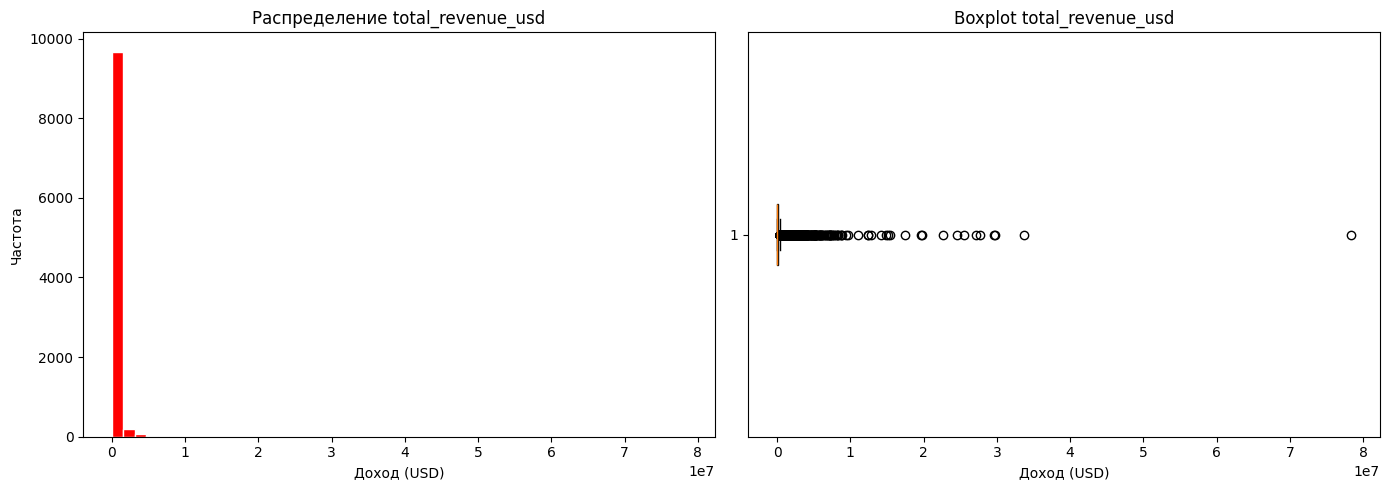

In [170]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма
axes[0].hist(df['total_revenue_usd'], bins=50, color='red', edgecolor='white')
axes[0].set_title('Распределение total_revenue_usd')
axes[0].set_xlabel('Доход (USD)')
axes[0].set_ylabel('Частота')

# Boxplot
axes[1].boxplot(df['total_revenue_usd'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='red'))
axes[1].set_title('Boxplot total_revenue_usd')
axes[1].set_xlabel('Доход (USD)')

plt.tight_layout()
plt.show()

In [171]:
print("Описательные статистики total_revenue_usd:")
print(df['total_revenue_usd'].describe())
print("\nАсимметрия (skewness):", df['total_revenue_usd'].skew())
print("Эксцесс (kurtosis):", df['total_revenue_usd'].kurtosis())

Описательные статистики total_revenue_usd:
count    1.000000e+04
mean     2.735412e+05
std      1.375941e+06
min      1.433000e+01
25%      1.174248e+04
50%      4.272418e+04
75%      1.504019e+05
max      7.838764e+07
Name: total_revenue_usd, dtype: float64

Асимметрия (skewness): 27.041796877100673
Эксцесс (kurtosis): 1192.4544895501554


Распределение дохода экстремально скошено. Для регрессии такое распределение неоптимально, поэтому применим **логарифмическое преобразование**.

### Логарифмирование целевой переменной

Преобразуем `total_revenue_usd` через `log(1 + x)`, чтобы приблизить распределение к нормальному и стабилизировать дисперсию.

Создадим логарифмированный таргет.

In [172]:
df['log_total_revenue'] = np.log1p(df['total_revenue_usd'])

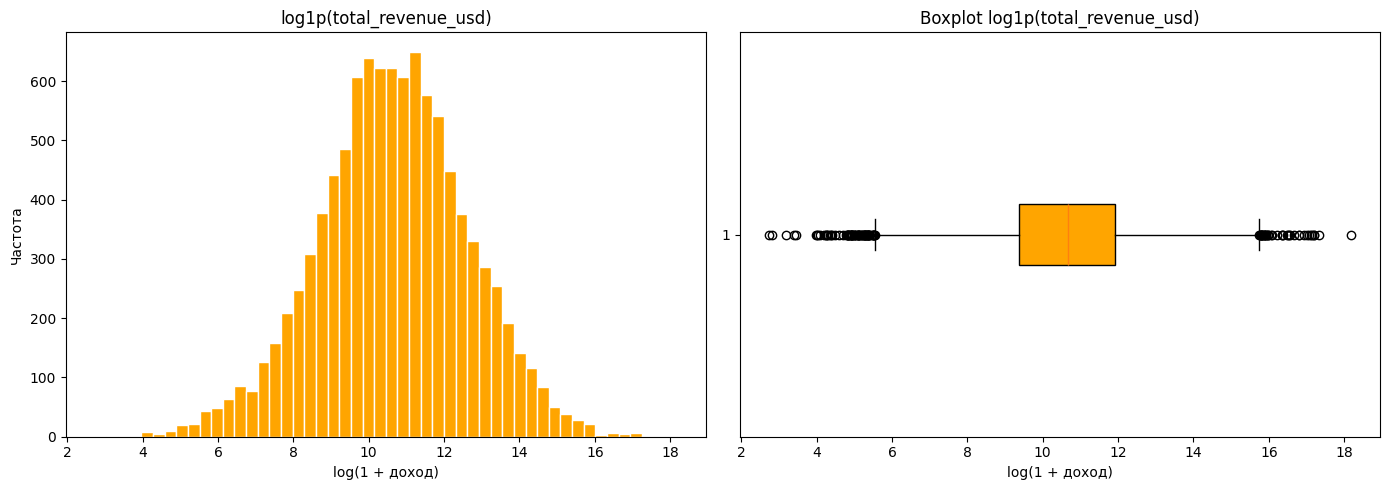

In [173]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['log_total_revenue'], bins=50, color='orange', edgecolor='white')
axes[0].set_title('log1p(total_revenue_usd)')
axes[0].set_xlabel('log(1 + доход)')
axes[0].set_ylabel('Частота')

axes[1].boxplot(df['log_total_revenue'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='orange'))
axes[1].set_title('Boxplot log1p(total_revenue_usd)')
axes[1].set_xlabel('log(1 + доход)')

plt.tight_layout()
plt.show()

In [174]:
print("Асимметрия после log1p:", df['log_total_revenue'].skew())
print("Эксцесс после log1p:", df['log_total_revenue'].kurtosis())

Асимметрия после log1p: -0.09981869409373771
Эксцесс после log1p: 0.17417388273962153


После `log1p` асимметрия значительно снизилась (с 27 до -0.1), эксцесс пришёл в норму.

Распределение стало ближе к нормальному.

## Feature Engineering

### Числовые признаки

#### Корреляция с целевой переменной

Исследуем, как числовые признаки связаны с логарифмированным доходом.

Сперва выберем числовые колонки, исключая исходный таргет.

In [175]:
num_cols = (
    df
    .select_dtypes(include=[np.number])
    .columns
    .drop(['total_revenue_usd'], errors='ignore')
    .tolist()
)

Исследуем корреляцию с `log_total_revenue`.

In [176]:
corr_with_target = df[num_cols].corrwith(df['log_total_revenue']).sort_values(ascending=False)
print("Топ-10 признаков по корреляции с log_total_revenue:")
print(corr_with_target.head(10))
print("\nТоп-10 антикоррелирующих:")
print(corr_with_target.tail(10))

Топ-10 признаков по корреляции с log_total_revenue:
log_total_revenue          1.000000
conversion_to_payer_pct    0.547389
price_usd                  0.465642
active_users_30d           0.394644
rating_count               0.392398
review_count               0.376857
arppu_usd                  0.299173
marketing_spend_usd        0.285190
arpu_usd                   0.270693
downloads                  0.266585
dtype: float64

Топ-10 антикоррелирующих:
retention_day30_pct      0.011318
retention_day1_pct       0.009899
ad_revenue_share_pct     0.008718
crash_rate_pct           0.006802
avg_session_minutes      0.005185
cpi_usd                  0.004422
update_frequency_days    0.000972
avg_daily_sessions      -0.001957
iap_revenue_share_pct   -0.007575
days_soft_to_release    -0.012471
dtype: float64


Построим тепловую карту корреляций.

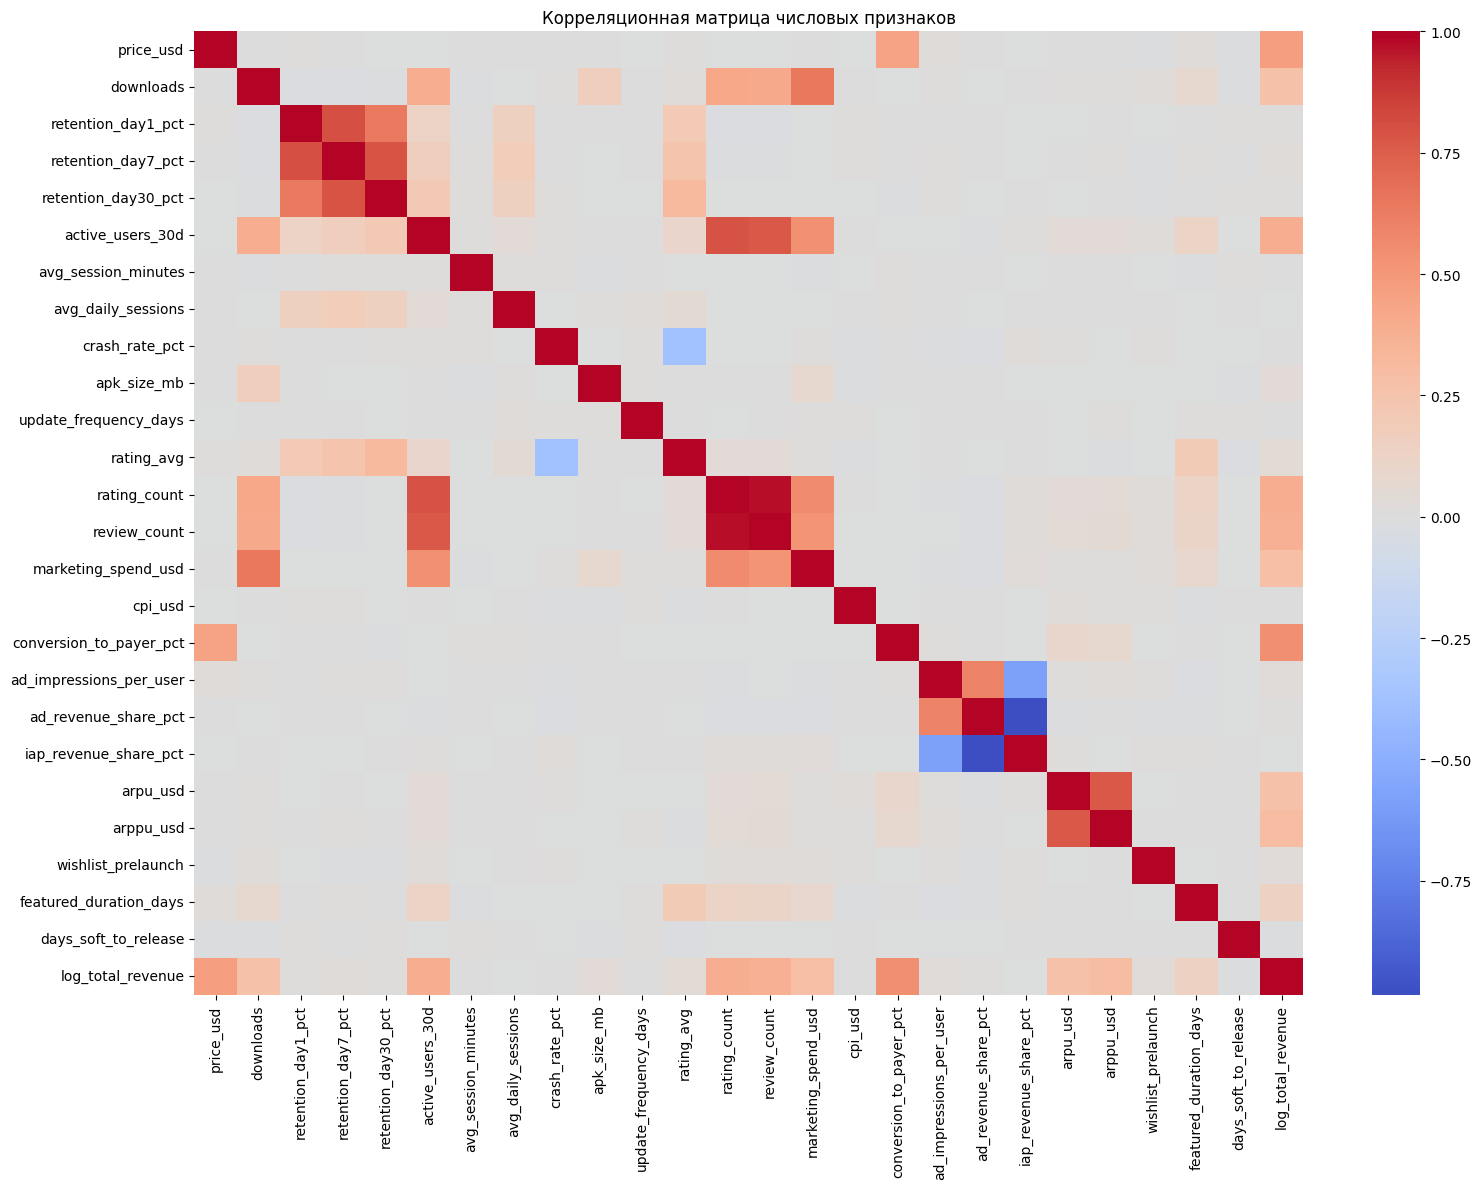

In [177]:
plt.figure(figsize=(16, 12))
sns.heatmap(df[num_cols].corr(), cmap='coolwarm', center=0, annot=False)
plt.title('Корреляционная матрица числовых признаков')
plt.tight_layout()
plt.show()

#### Анализ выбросов

Проверим числовые колонки на некорректные значения (например, отрицательная цена) и экстремальные выбросы.

In [178]:
check_cols = ['price_usd', 'crash_rate_pct', 'retention_day1_pct', 
              'retention_day7_pct', 'retention_day30_pct', 'ad_revenue_share_pct']
for col in check_cols:
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f"{col}: {neg_count} отрицательных значений")

price_usd: 10 отрицательных значений
crash_rate_pct: 10 отрицательных значений


Такие строки необходимо удалить, так как это явные ошибки.

In [179]:
df = df[(df['price_usd'] >= 0) & (df['crash_rate_pct'] >= 0)]
print("Форма после удаления некорректных значений:", df.shape)

Форма после удаления некорректных значений: (9980, 49)


Рассмотрим выбросы у признаков, которые наиболее коррелируют с целевой переменной.

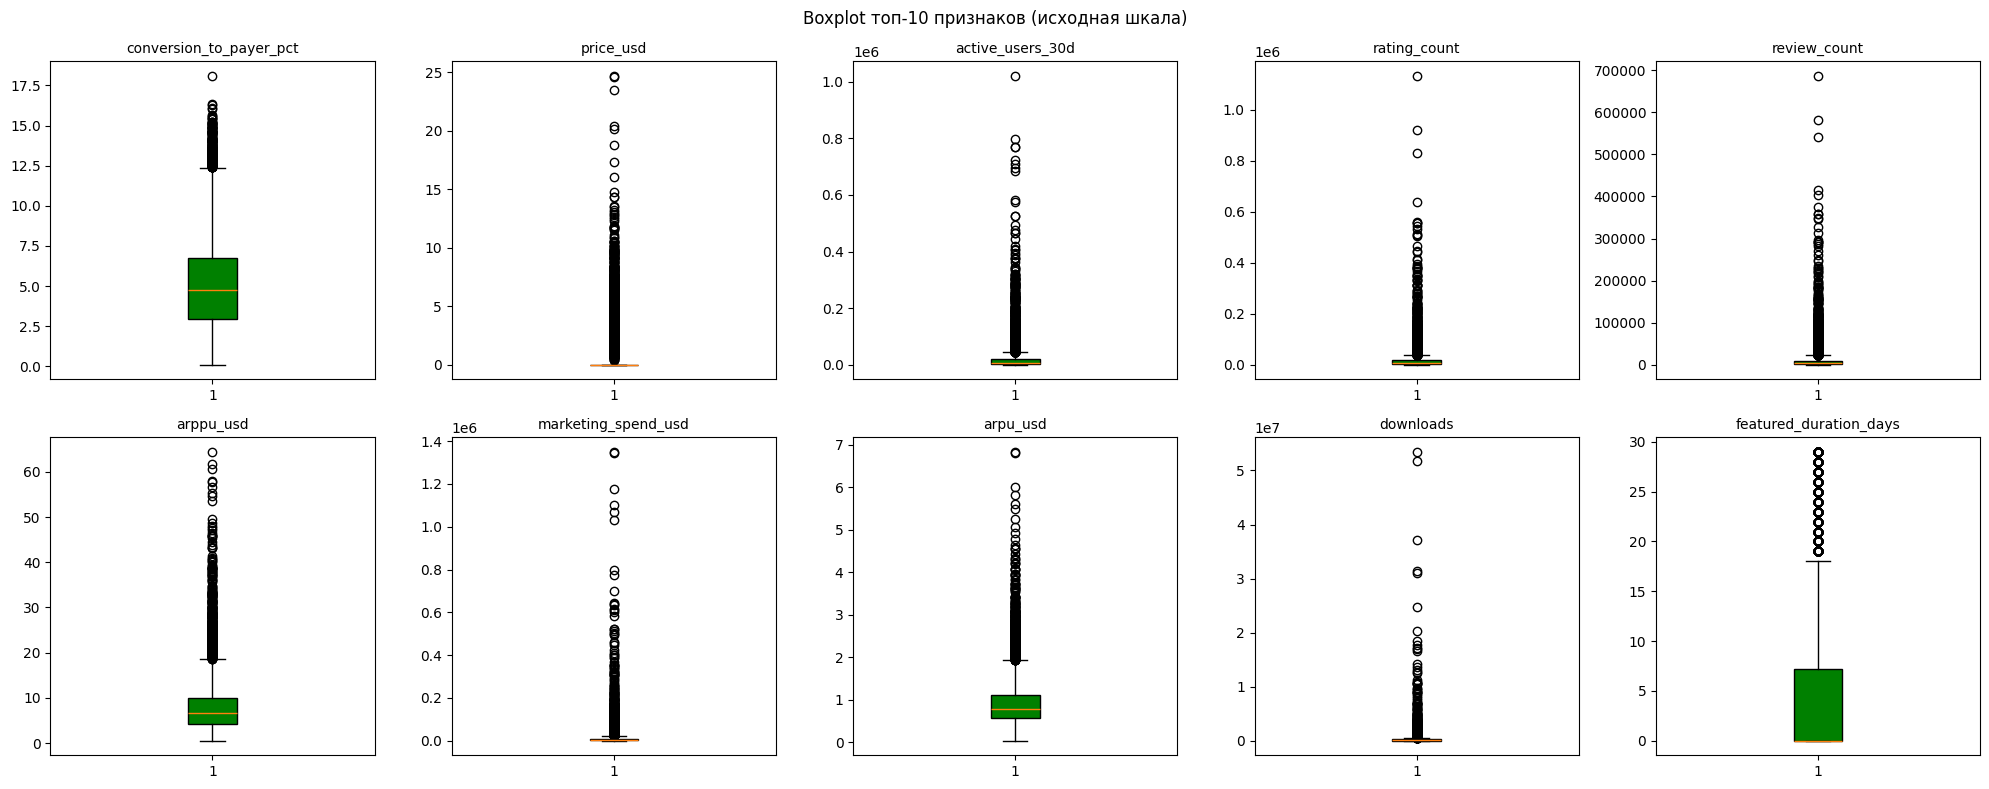

In [180]:
top_features = corr_with_target.drop('log_total_revenue').head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(top_features):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='green'))
    axes[i].set_title(col, fontsize=10)
plt.suptitle('Boxplot топ-10 признаков (исходная шкала)')
plt.tight_layout()
plt.show()

Из графика видно, что признаки `price_usd`, `active_users_30d`, `rating_count`, `review_count`, `marketing_spend_usd`, `downloads` имеют крайне много выбросов.

#### Повторное удаление утечек

Здесь было замечено, что у нас много столбцов с будущей информацией: `active_users_30d` и прочие. Если предсказывать доход **до релиза**, то их нужно удалить.

- **Пост-релизные метрики вовлечённости**: retention_day1/7/30_pct, active_users_30d, avg_session_minutes, avg_daily_sessions, crash_rate_pct.
- **Монетизационные результаты**: conversion_to_payer_pct, ad_impressions_per_user, ad_revenue_share_pct, iap_revenue_share_pct, arpu_usd, arppu_usd.
- **Популярность после релиза**: downloads, rating_avg, rating_count, review_count.
- **Продвижение магазином**: is_featured, featured_duration_days — решение принимается после релиза.
- **Частота обновлений**: update_frequency_days — становится известна со временем.

In [181]:
leakage_cols = [
    'retention_day1_pct', 'retention_day7_pct', 'retention_day30_pct',
    'active_users_30d', 'avg_session_minutes', 'avg_daily_sessions',
    'crash_rate_pct', 'conversion_to_payer_pct', 'ad_impressions_per_user',
    'ad_revenue_share_pct', 'iap_revenue_share_pct', 'arpu_usd', 'arppu_usd',
    'downloads', 'rating_avg', 'rating_count', 'review_count',
    'is_featured', 'featured_duration_days', 'update_frequency_days'
]


df = df.drop(columns=[col for col in leakage_cols if col in df.columns])
print("Форма после удаления утечек:", df.shape)

Форма после удаления утечек: (9980, 29)


#### Распределение оставшихся признаков

Теперь повторим код после удаления выбросов.

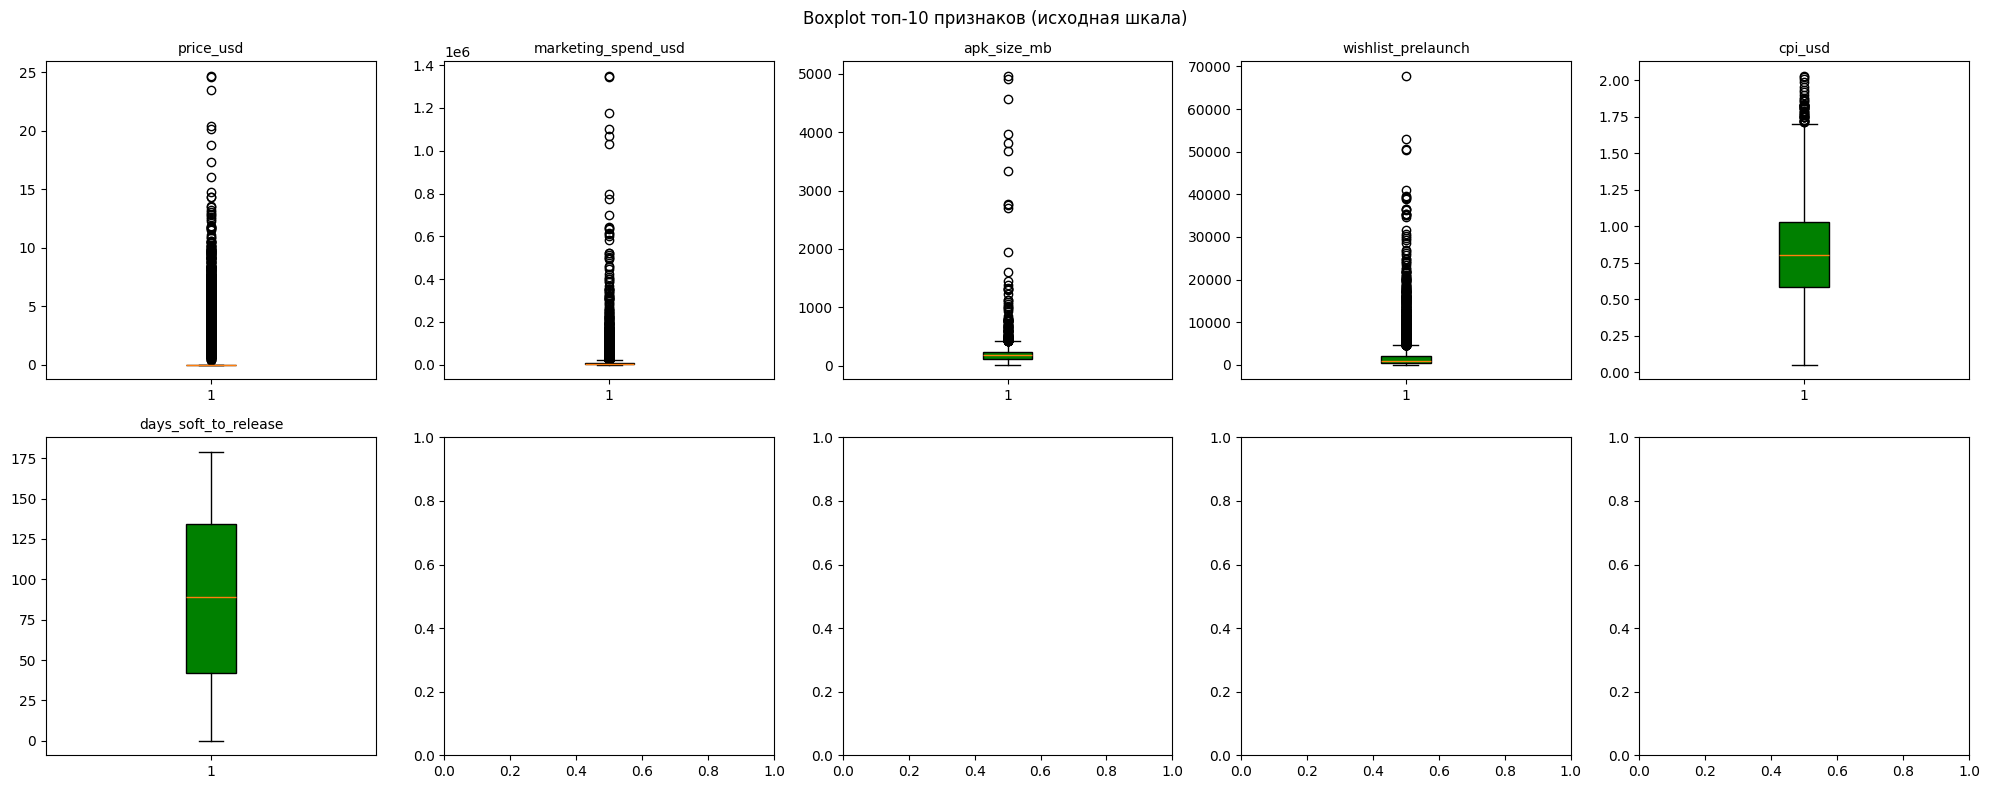

In [182]:
num_cols = (
    df
    .select_dtypes(include=[np.number])
    .columns
    .drop(['total_revenue_usd'], errors='ignore')
    .tolist()
)
corr_with_target = df[num_cols].corrwith(df['log_total_revenue']).sort_values(ascending=False)
top_features = corr_with_target.drop('log_total_revenue').head(10).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(top_features):
    axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='green'))
    axes[i].set_title(col, fontsize=10)
plt.suptitle('Boxplot топ-10 признаков (исходная шкала)')
plt.tight_layout()
plt.show()

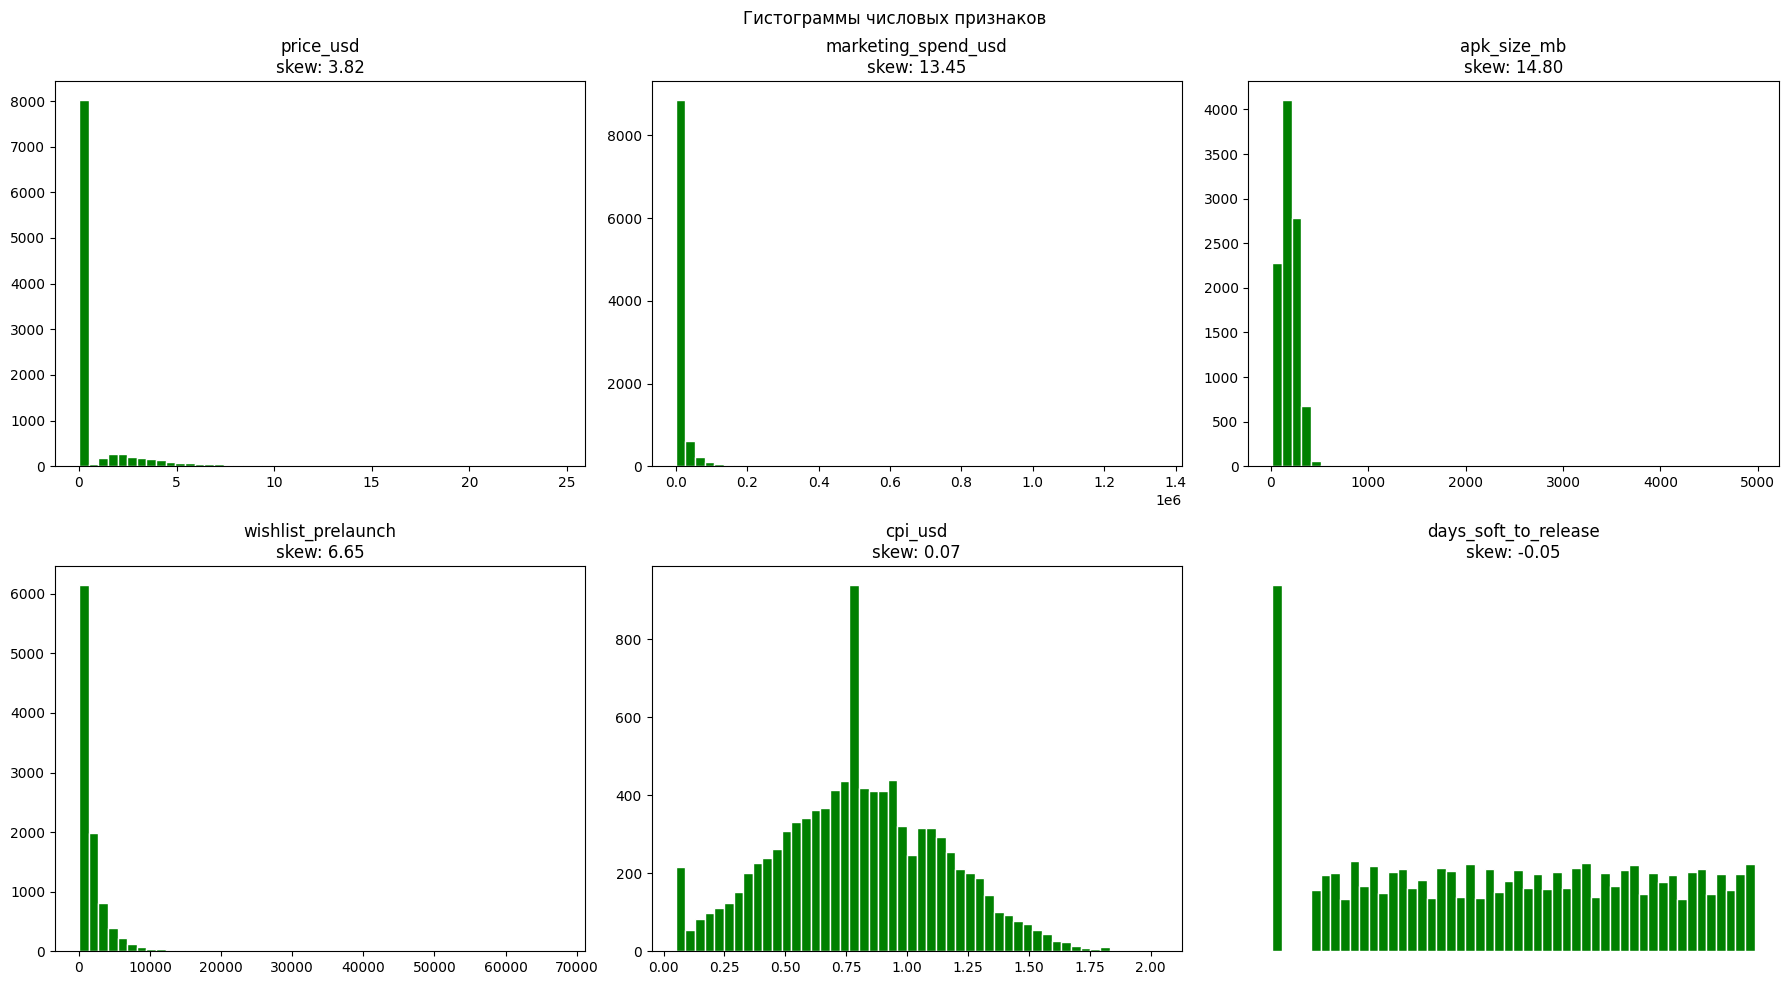

In [183]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(top_features):
    axes[i].hist(df[col], bins=50, color='green', edgecolor='white')
    axes[i].set_title(f'{col}\nskew: {df[col].skew():.2f}')
axes[-1].axis('off')
plt.suptitle('Гистограммы числовых признаков')
plt.tight_layout()
plt.show()

Отсюда видно, что высокую скошенность имеют `price_usd`, `marketing_spend_usd`, `apk_size_mb`, `wishlist_prelaunch`.

Также прологарифмируем их.

#### Логарифмирование числовых признаков

Применим `log1p` к скошенным признакам.

In [184]:
for col in ['price_usd', 'marketing_spend_usd', 'apk_size_mb', 'wishlist_prelaunch']:
    # Сохраним оригинал с суффиксом _raw
    df[f'{col}_raw'] = df[col]

    # Применям log1p
    df[col] = np.log1p(df[col])

Проверим асимметрию после преобразования.

In [185]:
for col in ['price_usd', 'marketing_spend_usd', 'apk_size_mb', 'wishlist_prelaunch']:
    print(f"{col}: skew после log1p = {df[col].skew():.2f}")

price_usd: skew после log1p = 1.97
marketing_spend_usd: skew после log1p = 0.05
apk_size_mb: skew после log1p = -1.30
wishlist_prelaunch: skew после log1p = 0.05


### Категориальные признаки

Изучим влияение категориальных характеристик на доход игры.

In [186]:
cat_cols = (
    df
    .select_dtypes(include=['category'])
    .columns.
    tolist()
)

Определим размер сетки.

In [187]:
n_cols = len(cat_cols)
n_rows = (n_cols + 2) // 3  # по 3 в ряд

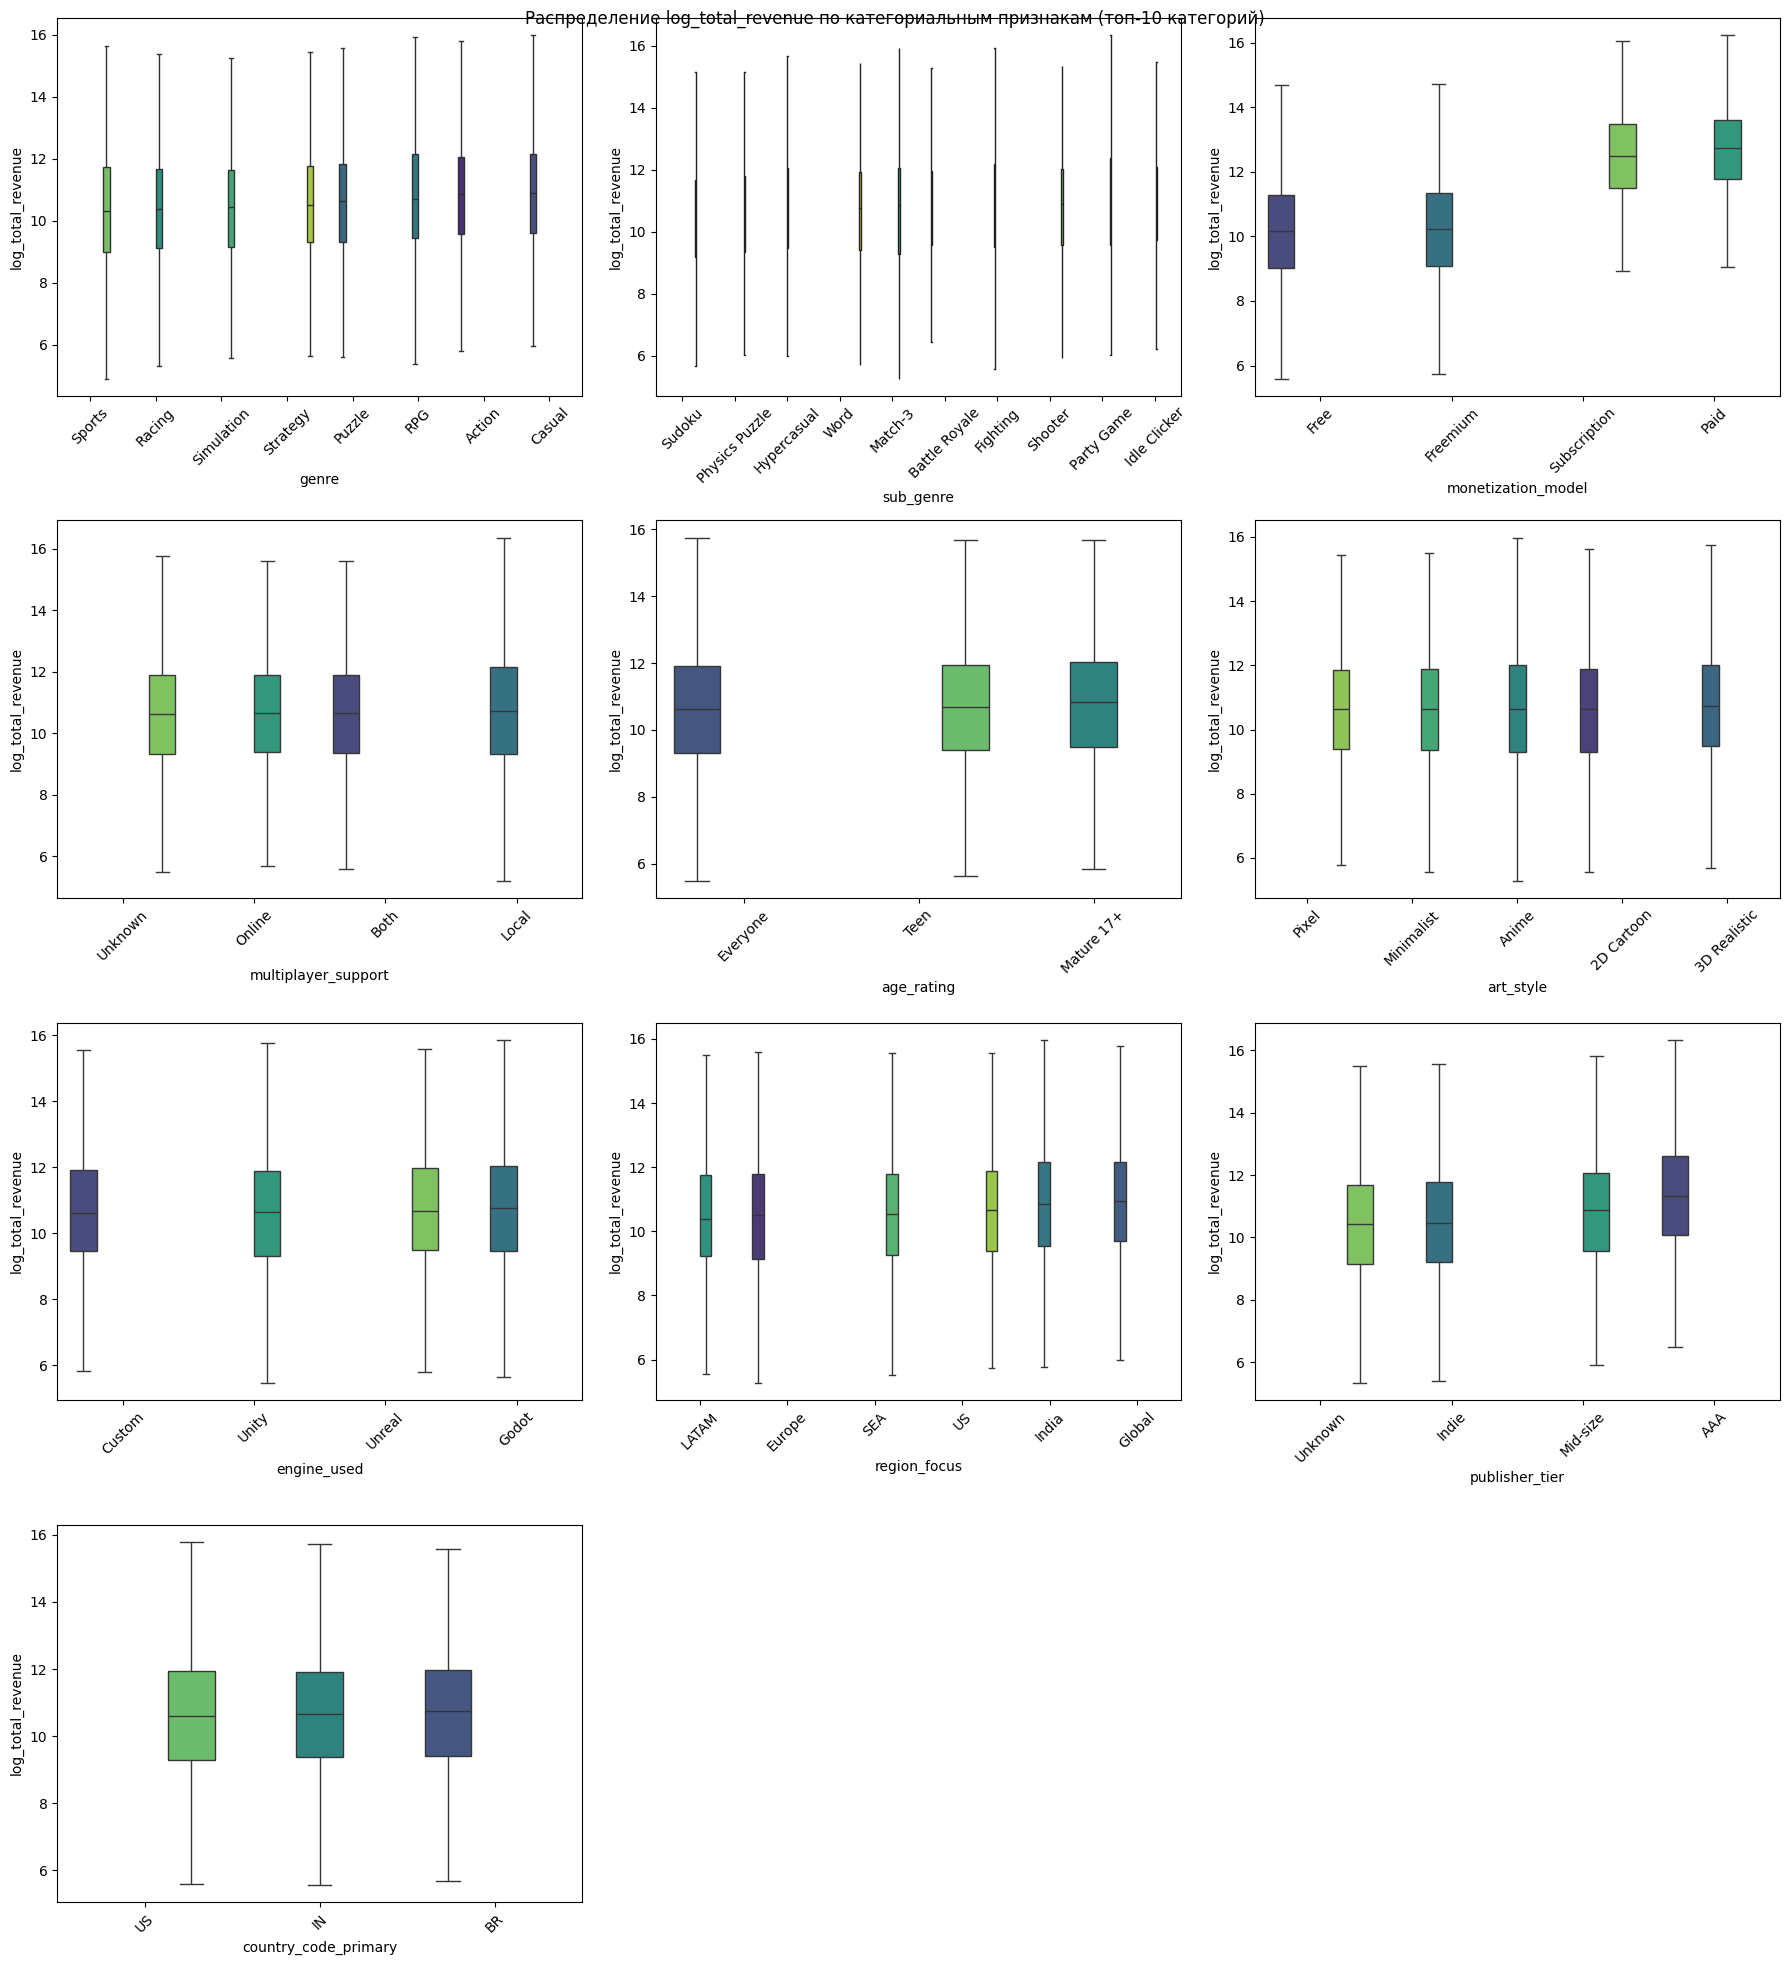

In [188]:
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5*n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    top_cats = df[col].value_counts().nlargest(10).index
    plot_data = df[df[col].isin(top_cats)]
    order = plot_data.groupby(col)['log_total_revenue'].median().sort_values().index
    sns.boxplot(x=col, y='log_total_revenue', data=plot_data, order=order, 
            hue=col, legend=False, ax=axes[i], palette='viridis', showfliers=False)

    axes[i].tick_params(axis='x', rotation=45)

# Убираем лишние пустые оси
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Распределение log_total_revenue по категориальным признакам (топ-10 категорий)')
plt.tight_layout()
plt.show()

В целом категориальные признаки выглядят информативными и будут включены в модель после кодирования.

### Извлечение признаков из дат

У нас остались две колонки с датами: `release_date` и `last_update_date`. Из них можно извлечь полезные числовые признаки:
* release_year, release_month, release_dayofweek (день недели выпуска)
* days_since_update (разница между последним обновлением и релизом)

Извлекаем признаки из даты релиза.

In [189]:
df['release_year'] = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['release_dayofweek'] = df['release_date'].dt.dayofweek  # 0=Пн, 6=Вс

Проверим `last_update_date`: если есть значения после release_date, то это утечка.

In [190]:
# Проверим last_update_date: если есть значения после release_date, это утечка
if (df['last_update_date'] > df['release_date']).any():
    print("last_update_date содержит даты после релиза -> утечка, удаляем")
    df = df.drop(columns=['last_update_date'])
else:
    # Если обновление до релиза (патч перед запуском), можно создать признак
    df['days_before_update'] = (df['release_date'] - df['last_update_date']).dt.days
    df = df.drop(columns=['last_update_date'])

last_update_date содержит даты после релиза -> утечка, удаляем


Удалим исходные даты.

In [191]:
df = df.drop(columns=['release_date'])

In [192]:
print("Оставшиеся колонки:", df.columns.tolist())

Оставшиеся колонки: ['developer_name', 'genre', 'sub_genre', 'monetization_model', 'contains_ads', 'has_in_app_purchases', 'multiplayer_support', 'age_rating', 'art_style', 'engine_used', 'region_focus', 'publisher_tier', 'was_featured_on_store', 'price_usd', 'apk_size_mb', 'marketing_spend_usd', 'cpi_usd', 'wishlist_prelaunch', 'total_revenue_usd', 'is_weekend_release', 'has_seasonal_event', 'cross_platform_available', 'cloud_save_support', 'country_code_primary', 'had_soft_launch', 'days_soft_to_release', 'log_total_revenue', 'price_usd_raw', 'marketing_spend_usd_raw', 'apk_size_mb_raw', 'wishlist_prelaunch_raw', 'release_year', 'release_month', 'release_dayofweek']


## Итог

Мы получили финальный набор из **34** колонок:

* Категориальные: genre, sub_genre, monetization_model, multiplayer_support, age_rating, art_style, engine_used, region_focus, publisher_tier, country_code_primary, а также булевы флаги (contains_ads, has_in_app_purchases, was_featured_on_store, is_weekend_release, has_seasonal_event, cross_platform_available, cloud_save_support, had_soft_launch).

* Текстовый (нужно закодировать отдельно): developer_name.

* Числовые (преобразованные): price_usd, apk_size_mb, marketing_spend_usd, wishlist_prelaunch (логарифмированы), cpi_usd, days_soft_to_release, release_year, release_month, release_dayofweek.

* Сырые версии: price_usd_raw и т.д. (для истории, в модель не пойдут).

* Целевая переменная: log_total_revenue (и исходная total_revenue_usd для справки).

Сохраним датасет.

In [193]:
import os

processed_dir = "../data/processed"
os.makedirs(processed_dir, exist_ok=True)
df.to_csv(os.path.join(processed_dir, "eda_processed.csv"), index=False)
print("Данные сохранены в", os.path.join(processed_dir, "eda_processed.csv"))

Данные сохранены в ../data/processed\eda_processed.csv
